<a href="https://colab.research.google.com/github/jonkrohn/ML-foundations/blob/master/notebooks/8-optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimization

This class, *Optimization*, is the eighth of eight classes in the *Machine Learning Foundations* series. It builds upon the material from each of the other classes in the series -- on linear algebra, calculus, probability, statistics, and algorithms -- in order to provide a detailed introduction to training machine learning models. 

Through the measured exposition of theory paired with interactive examples, you’ll develop a working understanding of all of the essential theory behind the ubiquitous gradient descent approach to optimization as well as how to apply it yourself — both at a granular, matrix operations level and a quick, abstract level — with TensorFlow and PyTorch. You’ll also learn about the latest optimizers, such as Adam and Nadam, that are widely-used for training deep neural networks. 

Over the course of studying this topic, you'll:

* Discover how the statistical and machine learning approaches to optimization differ, and why you would select one or the other for a given problem you’re solving.
* Understand exactly how the extremely versatile (stochastic) gradient descent optimization algorithm works, including how to apply it
* Get acquainted with the “fancy” optimizers that are available for advanced machine learning approaches (e.g., deep learning) and when you should consider using them.

Note that this Jupyter notebook is not intended to stand alone. It is the companion code to a lecture or to videos from Jon Krohn's [Machine Learning Foundations](https://github.com/jonkrohn/ML-foundations) series, which offer detail on the following:

*Segment 1: The Machine Learning Approach to Optimization*

* The Statistical Approach to Regression: Ordinary Least Squares
* When Statistical Approaches to Optimization Break Down
* The Machine Learning Solution 

*Segment 2: Gradient Descent*

* Objective Functions
* Cost / Loss / Error Functions
* Minimizing Cost with Gradient Descent
* Learning Rate
* Critical Points, incl. Saddle Points
* Gradient Descent from Scratch with PyTorch
* The Global Minimum and Local Minima
* Mini-Batches and Stochastic Gradient Descent (SGD)
* Learning Rate Scheduling
* Maximizing Reward with Gradient Ascent

*Segment 3: Fancy Deep Learning Optimizers*

* A Layer of Artificial Neurons in PyTorch
* Jacobian Matrices
* Hessian Matrices and Second-Order Optimization
* Momentum
* Nesterov Momentum
* AdaGrad
* AdaDelta 
* RMSProp
* Adam 
* Nadam
* Training a Deep Neural Net
* Resources for Further Study

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Segment 1: Optimization Approaches

See the [Ordinary Least Squares notes](06-introduction-to-statistics.ipynb#Ordinary-Least-Squares) in *Introduction to Statistics*.

## Segment 2: Gradient Descent

### Cost Functions

Fundamentally, for some instance $i$, we'd like to quantify the difference between the "correct" target model output $y_i$ and the model's predicted output $\hat{y}_i$. A first idea might be to take the simple difference: $$\Delta y_i = \hat{y}_i - y_i$$

For computational efficiency (we'll explore this later in the segment), in ML we seldom consider the cost associated with a single instance $i$. Instead, we typically consider several instances simultaneously, in which case calculating the simple difference is largely  ineffective because positive and negative $\Delta y_i$ values cancel out. E.g., consider a situation where: 

* $\Delta y_1 = \hat{y}_1 - y_1$ = 7 - 2 = 5
* $\Delta y_2 = \hat{y}_2 - y_2$ = 3 - 8 = -5

On an individual-instance basis, there are differences between the predicted and target outputs, indicating the model could be improved. Despite this, the total cost ($\Sigma \Delta y_i = \Delta y_1 + \Delta y_2 = 5-5$) is zero and therefore the mean cost ($\frac{\Sigma{\Delta y_i}}{n} = \frac{0}{2}$) is also zero, erroneously implying a perfect model fit.

#### Mean Absolute Error

A straightforward resolution to the simple-difference shortcoming is to take the absolute value of the difference. I.e., using the same contrived values as above: 

* $|\Delta y_1| = |\hat{y}_1 - y_1|$ = |7 - 2| = 5
* $|\Delta y_2| = |\hat{y}_2 - y_2|$ = |3 - 8| = 5

In this case:

* The total error is ten: $\Sigma |\Delta y_i| = |\Delta y_1| + |\Delta y_2| = 5+5$ 
* The **mean absolute error** (MAE) is five: $\frac{\Sigma{|\Delta y_i}|}{n} = \frac{10}{2}$

#### Mean Squared Error

While MAE satisfactorily quantifies cost across multiple instances, for reasons we'll numerate in a moment, it is much more common in ML to use **mean *squared* error** (MSE). 

Let's use the contrived values again to show how MSE is calculated. As covered in [*Calculus II*](https://github.com/jonkrohn/ML-foundations/blob/master/notebooks/4-calculus-ii.ipynb), the individual-instance variant of MSE is *squared error* or *quadratic cost*, which -- as with absolute error -- dictates that the cost for each instance $i$ must be $\geq 0$: 

* $(\hat{y}_1 - y_1)^2 = (7 - 2)^2 = 5^2 = 25$
* $(\hat{y}_2 - y_2)^2 = (3 - 8)^2 = (-5)^2 = 25$

As suggested by its name, MSE is the average: $$C = \frac{1}{n} \sum_{i=1}^n (\hat{y_i}-y_i)^2 = \frac{1}{2} (25 + 25) = \frac{50}{2} = 25 $$

Since cost for each instance $i$ must be $\geq 0$, MSE (as with MAE) must therefore also be $\geq 0$. In addition: 

1. The partial derivative of the MSE $C$ can be efficiently computed w.r.t. model parameters, providing a *gradient* of cost, $\nabla C$ (the primary focus of [*Calculus II*](https://github.com/jonkrohn/ML-foundations/blob/master/notebooks/4-calculus-ii.ipynb) is deriving $\nabla C$). Adjusting model parameters, we can *descend* $\nabla C$ and thereby minimize $C$ (the mechanics of which are the primary focus of *Optimization*).
2. Compared to MAE, MSE is relatively tolerant of small $\Delta y_i$ and intolerant of large $\Delta y_i$, a characteristic that tends to lead to better-fitting models.

In [2]:
delta_y = np.linspace(-5, 5, 1000)

In [3]:
abs_error = np.abs(delta_y)

In [4]:
sq_error = delta_y**2

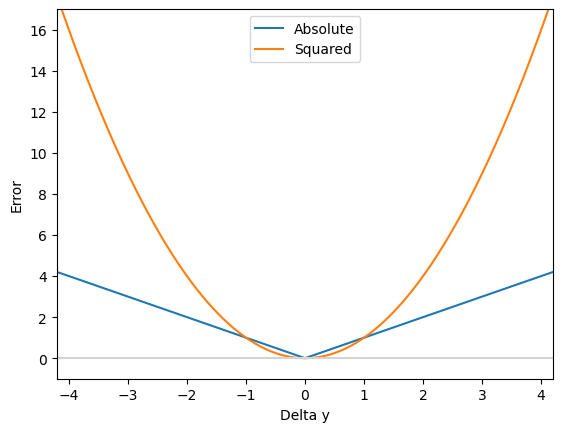

In [5]:
fig, ax = plt.subplots()

plt.plot(delta_y, abs_error)
plt.plot(delta_y, sq_error)
ax.axhline(c='lightgray')

plt.xlabel('Delta y')
plt.ylabel('Error')

ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-1, 17)
_ = ax.legend(['Absolute', 'Squared'])

There are other cost functions out there (e.g., [cross-entropy cost](https://github.com/the-deep-learners/deep-learning-illustrated/blob/master/notebooks/cross_entropy_cost.ipynb) is the typical choice for a deep learning classifier), but since MSE is the most common, including being the default option for regression models, it will be our focus for the remainder of *ML Foundations*.

### Minimizing Cost with Gradient Descent

This part is similar to the Batch Regression Gradient notebook with the critical exception that we optimize via gradient descent without relying on the built-in PyTorch SGD() optimizer.

In [6]:
import torch
import matplotlib.pyplot as plt

In [7]:
xs = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7.])
ys = torch.tensor([1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37])

In [8]:
def regression(my_x, my_m, my_b):
    return my_m*my_x + my_b

In [9]:
m = torch.tensor([0.9]).requires_grad_()
b = torch.tensor([0.1]).requires_grad_()

**Step 1**: Forward pass

In [10]:
yhats = regression(xs, m, b)
yhats

tensor([0.1000, 1.0000, 1.9000, 2.8000, 3.7000, 4.6000, 5.5000, 6.4000],
       grad_fn=<AddBackward0>)

**Step 2**: Compare $\hat{y}$ with true $y$ to calculate cost $C$

Mean squared error: $$C = \frac{1}{n} \sum_{i=1}^n (\hat{y_i}-y_i)^2 $$

In [11]:
def mse(my_yhat, my_y): 
    sigma = torch.sum((my_yhat - my_y)**2)
    return sigma/len(my_y)

In [12]:
C = mse(yhats, ys)
C

tensor(19.6755, grad_fn=<DivBackward0>)

**Step 3**: Use autodiff to calculate gradient of $C$ w.r.t. parameters

In [13]:
C.backward()

In [14]:
m.grad

tensor([36.3050])

$\frac{\partial C}{\partial m} = 36.3$ indicates that an increase in $m$ corresponds to a large increase in $C$. 

In [15]:
b.grad

tensor([6.2650])

Meanwhile, $\frac{\partial C}{\partial b} = 6.26$ indicates that an increase in $b$ also corresponds to an increase in $C$, though much less so than $m$.

(Using partial derivatives derived in [*Calculus II*](https://github.com/jonkrohn/ML-foundations/blob/master/notebooks/4-calculus-ii.ipynb), we could alternatively calculate these same slopes without automatic numerical computation:)

$$ \frac{\partial C}{\partial m} = \frac{2}{n} \sum (\hat{y}_i - y_i) \cdot x_i $$

In [16]:
2*1/len(ys)*torch.sum((yhats - ys)*xs)

tensor(36.3050, grad_fn=<MulBackward0>)

$$ \frac{\partial C}{\partial b} = \frac{2}{n} \sum (\hat{y}_i - y_i) $$

In [17]:
2*1/len(ys)*torch.sum(yhats - ys)

tensor(6.2650, grad_fn=<MulBackward0>)

The gradient of cost, $\nabla C$, is: 

In [18]:
gradient = torch.tensor([[b.grad.item(), m.grad.item()]]).T
gradient

tensor([[ 6.2650],
        [36.3050]])

For convenience, model parameters are often denoted as $\boldsymbol{\theta}$, which, depending on the model, could be, for example, a vector, a matrix, or a collection of tensors of varying dimensions. With our simple linear model, a vector tensor will do:

In [19]:
theta = torch.tensor([[b, m]]).T 
theta

/var/folders/sd/6w8v27q940q9w4jwh6y88y980000gn/T/ipykernel_5545/1370584101.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772252277482/work/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  theta = torch.tensor([[b, m]]).T


tensor([[0.1000],
        [0.9000]])

Note the gradient $\nabla C$ could thus alternatively be denoted with respect to $\boldsymbol{\theta}$ as $\nabla_{\boldsymbol{\theta}} f(\boldsymbol{\theta})$.

(Also, note that we're transposing $\boldsymbol{\theta}$ to make forthcoming tensor operations easier because of the convention in ML to transpose the gradient, $\nabla C$.)

Let's visualize the state of the most pertinent metrics in a single plot: 

In [20]:
def labeled_regression_plot(my_x, my_y, my_m, my_b, my_C, include_grad=True):
    
    title = 'Cost = {}'.format('%.3g' % my_C.item())
    if include_grad:
        xlabel = 'm = {}, m grad = {}'.format('%.3g' % my_m.item(), '%.3g' % my_m.grad.item())
        ylabel = 'b = {}, b grad = {}'.format('%.3g' % my_b.item(), '%.3g' % my_b.grad.item())
    else:
        xlabel = 'm = {}'.format('%.3g' % my_m.item())        
        ylabel = 'b = {}'.format('%.3g' % my_b.item())
    
    fig, ax = plt.subplots()
    
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)

    ax.scatter(my_x, my_y)
    
    x_min, x_max = ax.get_xlim()
    y_min = regression(x_min, my_m, my_b).detach().numpy()
    y_max = regression(x_max, my_m, my_b).detach().numpy()

    ax.set_xlim([x_min, x_max])
    _ = ax.plot([x_min, x_max], [y_min, y_max], c='C01')

**Step 4**: Gradient descent

In the first round of training, with $\frac{\partial C}{\partial m} = 36.3$ and $\frac{\partial C}{\partial b} = 6.26$, the lowest hanging fruit with respect to reducing cost $C$ is to decrease the slope of the regression line, $m$. The model would also benefit from a comparatively small decrease in the $y$-intercept of the line, $b$. 

To control exactly how much we adjust the model parameters $\boldsymbol{\theta}$, we set a **learning rate**, a hyperparameter of ML models that use gradient descent (that is typically denoted with $\alpha$): 

In [21]:
lr = 0.01 # Cover rules of thumb

We use the learning rate $\alpha$ to scale the gradient, i.e., $\alpha \nabla C$:

In [22]:
scaled_gradient = lr * gradient
scaled_gradient

tensor([[0.0626],
        [0.3630]])

We can now use our scaled gradient to adjust our model parameters $\boldsymbol{\theta}$ in directions that will reduce the model cost $C$. 

Since, e.g., $\frac{\partial C}{\partial m} = 36.3$ indicates that increasing the slope parameter $m$ corresponds to an increase in cost $C$, we *subtract* the gradient to adjust each individual parameter in a direction that reduces cost: $$ \boldsymbol{\theta}' = \boldsymbol{\theta} - \alpha \nabla C$$

In [23]:
new_theta = theta - scaled_gradient
new_theta

tensor([[0.0374],
        [0.5369]])

To see these adjustments even more clearly, you can consider each parameter individually, e.g., $m' = m - \alpha \frac{\partial C}{\partial m}$:

In [24]:
m - lr*m.grad

tensor([0.5369], grad_fn=<SubBackward0>)

...and $b' = b - \alpha \frac{\partial C}{\partial b}$: 

In [25]:
b - lr*b.grad

tensor([0.0374], grad_fn=<SubBackward0>)

With our updated parameters $\boldsymbol{\theta}$ now in hand, we can use them to check that they do indeed correspond to a decreased cost $C$:

In [26]:
b = new_theta[0]
m = new_theta[1]

In [27]:
C = mse(regression(xs, m, b), ys)

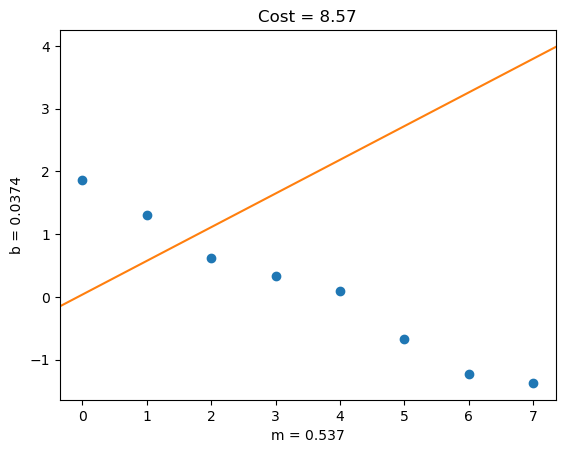

In [28]:
labeled_regression_plot(xs, ys, m, b, C, include_grad=False) # Gradient of C hasn't been recalculated

#### Rinse and Repeat

To perform another round of gradient descent, we let PyTorch know we'd like to track gradients on the tensors `b` and `m` (as we did at the top of the notebook when we created them the first time): 

In [29]:
b.requires_grad_()
_ = m.requires_grad_() # "_ =" is to prevent output within Jupyter; it is cosmetic only

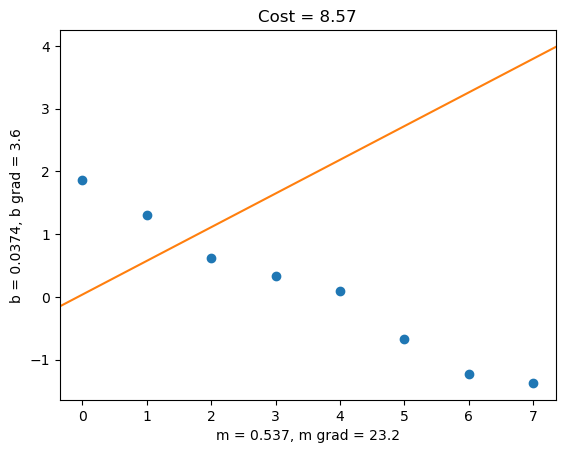

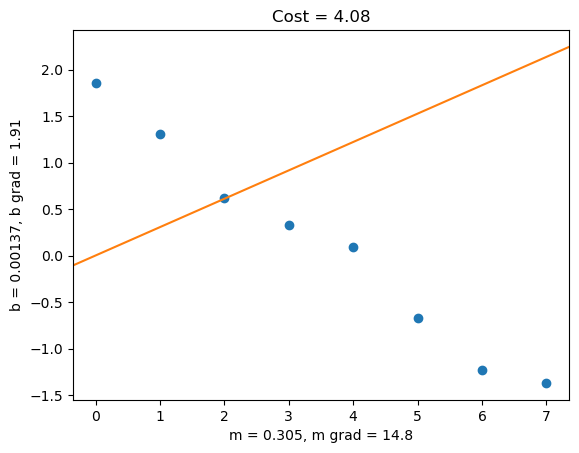

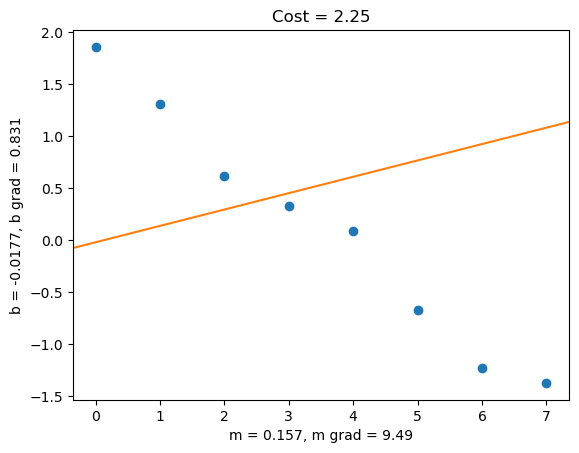

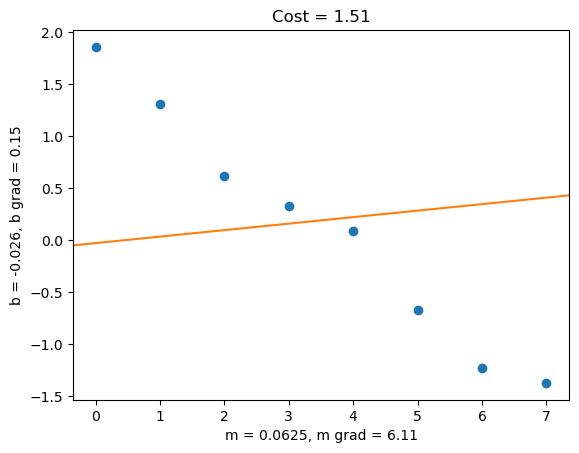

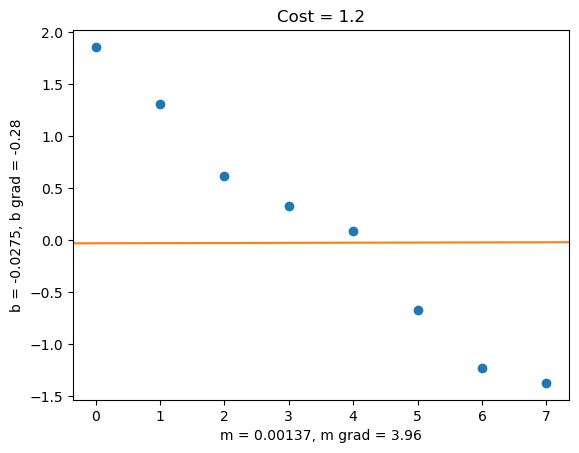

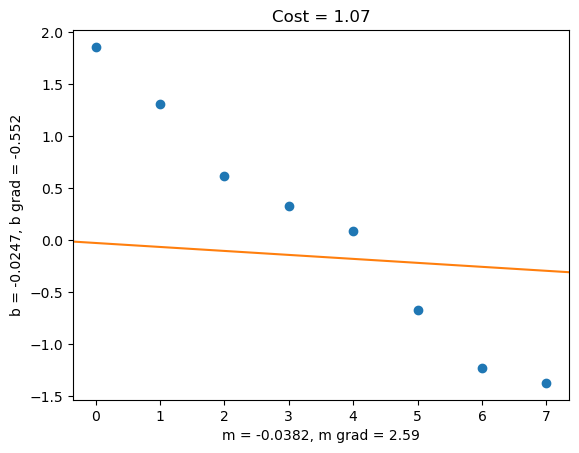

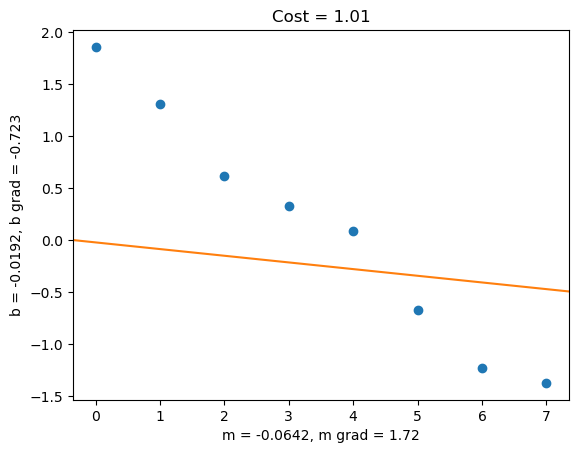

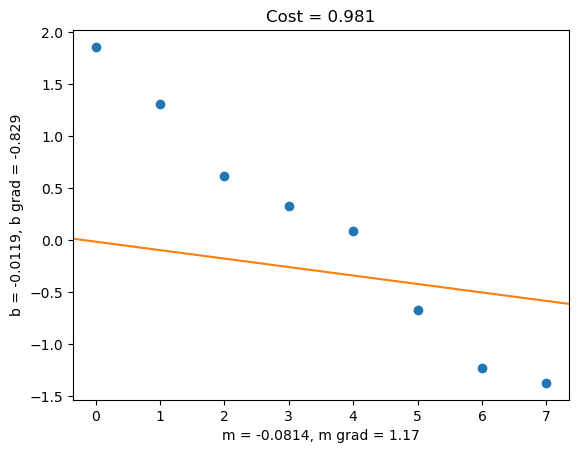

In [30]:
epochs = 8
for epoch in range(epochs): 
    
    yhats = regression(xs, m, b) # Step 1
    C = mse(yhats, ys) # Step 2
    
    C.backward() # Step 3
    
    labeled_regression_plot(xs, ys, m, b, C)
    
    gradient = torch.tensor([[b.grad.item(), m.grad.item()]]).T
    theta = torch.tensor([[b, m]]).T 
    
    new_theta = theta - lr*gradient # Step 4
    
    b = new_theta[0].requires_grad_()
    m = new_theta[1].requires_grad_()

(Note that the above plots are identical to those in the [*Batch Regression Gradient* notebook](https://github.com/jonkrohn/ML-foundations/blob/master/notebooks/batch-regression-gradient.ipynb), in which we used the PyTorch `SGD()` method to descend the gradient.)

In later rounds of training, after the model's slope $m$ has become closer to the slope represented by the data, $\frac{\partial C}{\partial b}$ becomes negative, indicating an inverse relationship between $b$ and $C$. Meanwhile, $\frac{\partial C}{\partial m}$ remains positive. 

This combination directs gradient descent to simultaneously adjust the $y$-intercept $b$ upwards and the slope $m$ downwards in order to reduce cost $C$ and, ultimately, fit the regression line snugly to the data. 

Finally, let's run a thousand more epochs (without plots) to converge on optimal parameters $\boldsymbol{\theta}$: 

In [31]:
epochs = 992 # accounts for rounds above to match 1000 epochs of regression-in-pytorch.ipynb
for epoch in range(epochs):
    
    yhats = regression(xs, m, b) # Step 1
    C = mse(yhats, ys) # Step 2
    
    C.backward() # Step 3
    
    print('Epoch {}, cost {}, m grad {}, b grad {}'.format(epoch, '%.3g' % C.item(), '%.3g' % m.grad.item(), '%.3g' % b.grad.item()))
    
    gradient = torch.tensor([[b.grad.item(), m.grad.item()]]).T
    theta = torch.tensor([[b, m]]).T 
    
    new_theta = theta - lr*gradient # Step 4
    
    b = new_theta[0].requires_grad_()
    m = new_theta[1].requires_grad_()

Epoch 0, cost 0.962, m grad 0.82, b grad -0.894
Epoch 1, cost 0.948, m grad 0.595, b grad -0.934
Epoch 2, cost 0.936, m grad 0.452, b grad -0.957
Epoch 3, cost 0.925, m grad 0.361, b grad -0.969
Epoch 4, cost 0.915, m grad 0.302, b grad -0.975
Epoch 5, cost 0.904, m grad 0.265, b grad -0.977
Epoch 6, cost 0.894, m grad 0.241, b grad -0.976
Epoch 7, cost 0.884, m grad 0.225, b grad -0.973
Epoch 8, cost 0.874, m grad 0.214, b grad -0.969
Epoch 9, cost 0.864, m grad 0.207, b grad -0.965
Epoch 10, cost 0.854, m grad 0.202, b grad -0.96
Epoch 11, cost 0.845, m grad 0.199, b grad -0.955
Epoch 12, cost 0.835, m grad 0.196, b grad -0.95
Epoch 13, cost 0.826, m grad 0.194, b grad -0.945
Epoch 14, cost 0.817, m grad 0.192, b grad -0.939
Epoch 15, cost 0.808, m grad 0.191, b grad -0.934
Epoch 16, cost 0.799, m grad 0.189, b grad -0.929
Epoch 17, cost 0.79, m grad 0.188, b grad -0.923
Epoch 18, cost 0.781, m grad 0.187, b grad -0.918
Epoch 19, cost 0.772, m grad 0.186, b grad -0.913
Epoch 20, cost

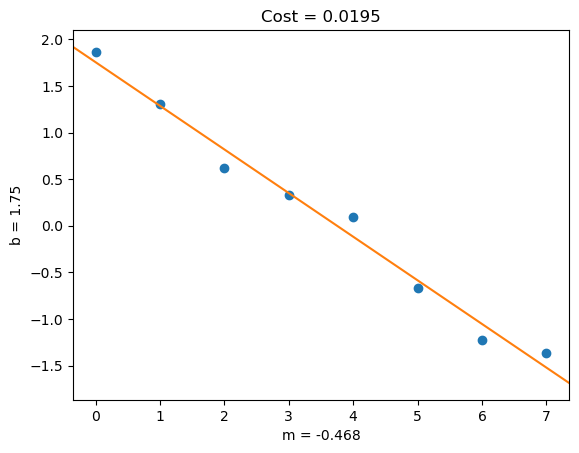

In [32]:
labeled_regression_plot(xs, ys, m, b, C, include_grad=False)

(Note that the above results are identical to those in the [*Batch Regression Gradient* notebook](https://github.com/jonkrohn/ML-foundations/blob/master/notebooks/batch-regression-gradient.ipynb), in which we also used the PyTorch `SGD()` method to descend the gradient.)

### Critical Points

#### Minimum

In [33]:
x = np.linspace(-10, 10, 1000)

If $y = x^2 + 3x + 4$...

In [34]:
y_min = x**2 + 3*x + 4

...then $y' = 2x + 3$. 

Critical point is located where $y' = 0$, so where $2x + 3 = 0$.

Rearranging to solve for $x$:
$$2x = -3$$
$$x = \frac{-3}{2} = -1.5$$

At which point, $y = x^2 + 3x + 4 = (-1.5)^2 + 3(-1.5) + 4 = 1.75$

Thus, the critical point is located at (-1.5, 1.75).

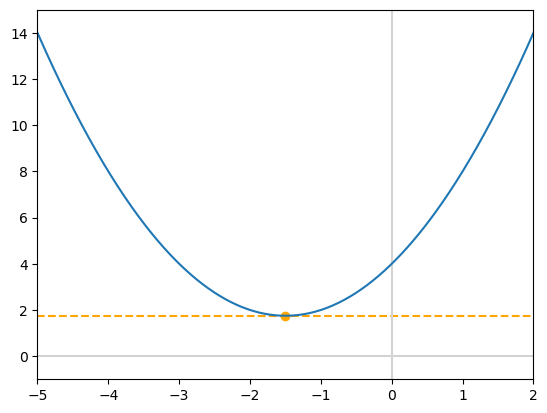

In [35]:
fig, ax = plt.subplots()

plt.scatter(-1.5, 1.75, c='orange')
plt.axhline(y=1.75, c='orange', linestyle='--')

plt.axvline(x=0, c='lightgray')
plt.axhline(y=0, c='lightgray')

ax.set_xlim(-5, 2)
ax.set_ylim(-1, 15)

_ = ax.plot(x, y_min)

#### Maximum

If $y = -x^2 + 3x + 4$...

In [36]:
y_max = -x**2 + 3*x + 4

...then $y' = -2x + 3$. 

Critical point is located where $y' = 0$, so where $-2x + 3 = 0$.

Rearranging to solve for $x$:
$$-2x = -3$$
$$x = \frac{-3}{-2} = 1.5$$

At which point, $y = -x^2 + 3x + 4 = -(1.5)^2 + 3(1.5) + 4 = 6.25$

Thus, the critical point is located at (1.5, 6.25).

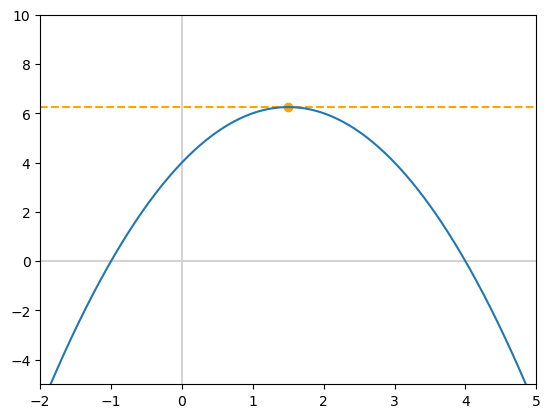

In [37]:
fig, ax = plt.subplots()

plt.scatter(1.5, 6.25, c='orange')
plt.axhline(y=6.25, c='orange', linestyle='--')

plt.axvline(x=0, c='lightgray')
plt.axhline(y=0, c='lightgray')

ax.set_xlim(-2, 5)
ax.set_ylim(-5, 10)

_ = ax.plot(x, y_max)

#### Saddle point

If $y = x^3 + 6$...

In [38]:
y_sp = x**3 + 6

...then $y' = 3x^2$. 

Critical point is located where $y' = 0$, so where $3x^2 = 0$.

Rearranging to solve for $x$:
$$x^2 = \frac{0}{3} = 0$$
$$x = \sqrt{0} = 0$$

At which point, $y = x^3 + 6 = (0)^3 + 6 = 6$

Thus, the critical point is located at (0, 6).

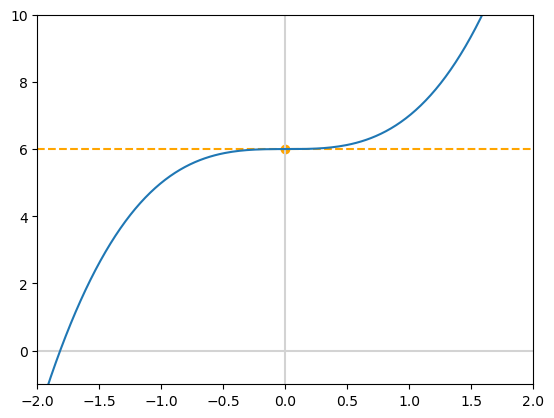

In [39]:
fig, ax = plt.subplots()

plt.scatter(0, 6, c='orange')
plt.axhline(y=6, c='orange', linestyle='--')

plt.axvline(x=0, c='lightgray')
plt.axhline(y=0, c='lightgray')

ax.set_xlim(-2, 2)
ax.set_ylim(-1, 10)

_ = ax.plot(x, y_sp)

### Stochastic Gradient Descent

This notebook expands  upon the Gradient Descent from the previous section to introduce *stochastic* gradient descent (SGD).

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [41]:
torch.manual_seed(42)
np.random.seed(42)

#### Simulate data

Create a vector tensor `x` with eight million points spaced evenly from zero to eight:

In [42]:
n = 8000000

In [43]:
x = torch.linspace(0., 8., n) # using typical 'x' convention for vector instead of 'xs'

Use the same line equation as in the [*Regression in PyTorch* notebook](https://github.com/jonkrohn/ML-foundations/blob/master/notebooks/regression-in-pytorch.ipynb) to simulate eight million $y$ values for the vector `y`. That is, $m = -0.5$ and $b = 2$:
$$y = mx + b + \epsilon = -0.5x + 2 + \mathcal{N}(0, 1)$$

$\mathcal{N}(0,1)$ means a **Normal (Gaussian) distribution** with:

- mean $0$
- variance $1$ (so standard deviation $1$)

In the formula
$$
y = mx + b + \epsilon,
$$
the noise term is typically written as
$$
\epsilon \sim \mathcal{N}(0,1).
$$

Using per-sample probability notation:
$$
\epsilon_i \overset{\mathrm{iid}}{\sim} \mathcal{N}(0,1), \quad
y_i = mx_i + b + \epsilon_i.
$$

Equivalent conditional form:
$$
y_i \mid x_i \sim \mathcal{N}(mx_i+b,\;1).
$$

So for each $x_i$, a random noise value is sampled from $\mathcal{N}(0,1)$ and added to the line $mx_i+b$. This creates realistic scatter around the underlying linear trend.

For a deeper treatment, see the section [Gaussian or Normal Distribution](05-probability-and-information-theory.ipynb#gaussian-or-normal-distribution) in the probability notebook.

In [44]:
y = -0.5*x + 2 + torch.normal(mean=torch.zeros(n), std=1) # 'y' vector instead of 'ys'

Let's randomly sample a couple thousand points for the purpose of data visualization:

In [45]:
indices = np.random.choice(n, size=2000, replace=False)

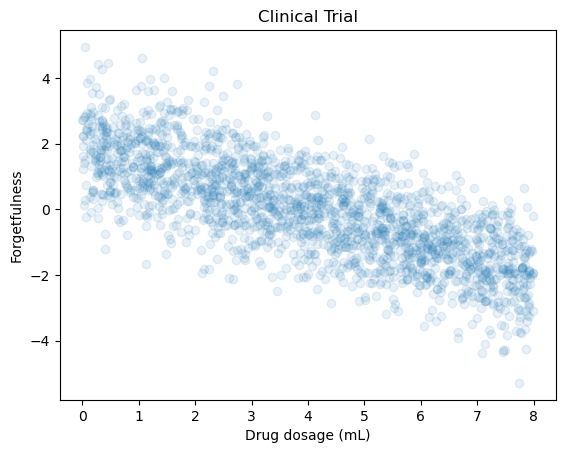

In [46]:
fig, ax = plt.subplots()
plt.title("Clinical Trial")
plt.xlabel("Drug dosage (mL)")
plt.ylabel("Forgetfulness")
_ = ax.scatter(x[indices], y[indices], alpha=0.1)

#### Define model and "randomly" initialize model parameters

In [47]:
def regression(my_x, my_m, my_b):
    return my_m*my_x + my_b

In [48]:
m = torch.tensor([0.9]).requires_grad_()
b = torch.tensor([0.1]).requires_grad_()

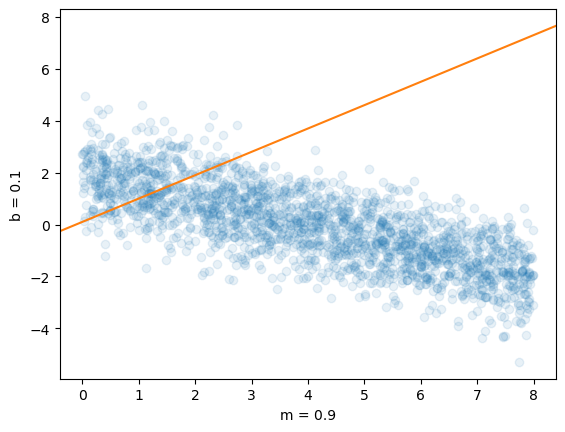

In [49]:
fig, ax = plt.subplots()

ax.scatter(x[indices], y[indices], alpha=0.1)

x_min, x_max = ax.get_xlim()
y_min = regression(x_min, m, b).detach().numpy() # detach() stops requiring grad on Tensor (required before conversion to plottable Numpy array)
y_max = regression(x_max, m, b).detach().numpy()

plt.ylabel('b = {}'.format('%.3g' % b.item()))
plt.xlabel('m = {}'.format('%.3g' % m.item()))

ax.set_xlim([x_min, x_max])
_ = ax.plot([x_min, x_max], [y_min, y_max], c='C01')

#### Optimize parameters via SGD

Randomly (*stochastically*) sample a mini-batch of data for gradient descent:

In [50]:
batch_size = 32 # model hyperparameter

Sample without replacement. If you run out of data (which we won't in this example because we'll do 100 rounds of training so use 3200 data points, 0.04% of the 8m), commence another epoch with the full complement of data (we'll cover this in later NBs).

In [51]:
batch_indices = np.random.choice(n, size=batch_size, replace=False)

In [52]:
x[batch_indices]

tensor([7.2894, 3.4176, 4.5081, 4.0586, 4.2343, 0.7974, 2.4974, 6.3466, 4.6832,
        7.6599, 5.1981, 1.7992, 1.1342, 6.7925, 5.6772, 6.2090, 7.1356, 7.6577,
        4.8597, 7.0404, 7.9052, 1.5491, 6.3357, 5.8022, 1.9294, 3.2062, 5.1424,
        4.9199, 1.9978, 1.1224, 2.1819, 0.2313])

Other than sampling a mini-batch, we optimize by following identical steps to those in the *Gradient Descent from Scratch* notebook:

**Step 1**: Forward pass

In [53]:
yhat = regression(x[batch_indices], m, b)
yhat

tensor([6.6605, 3.1759, 4.1573, 3.7528, 3.9109, 0.8176, 2.3477, 5.8119, 4.3149,
        6.9939, 4.7783, 1.7193, 1.1208, 6.2132, 5.2095, 5.6881, 6.5220, 6.9919,
        4.4737, 6.4363, 7.2147, 1.4942, 5.8021, 5.3220, 1.8364, 2.9856, 4.7282,
        4.5279, 1.8980, 1.1101, 2.0637, 0.3082], grad_fn=<AddBackward0>)

**Step 2**: Compare $\hat{y}$ with true $y$ to calculate cost $C$

In [54]:
def mse(my_yhat, my_y):
    sigma = torch.sum((my_yhat - my_y)**2)
    return sigma/len(my_y)

In [55]:
C = mse(yhat, y[batch_indices])
C

tensor(30.6121, grad_fn=<DivBackward0>)

In [56]:
def labeled_regression_plot(my_x, my_y, my_m, my_b, my_C, include_grad=True):

    # Convert tensors to numpy arrays using detach():
    x_np = my_x.detach().numpy()
    y_np = my_y.detach().numpy()
    m_val = my_m.detach()
    b_val = my_b.detach()
    C_val = my_C.detach()

    title = 'Cost = {}'.format('%.3g' % C_val.item())
    if include_grad:
        xlabel = 'm = {}, m grad = {}'.format('%.3g' % m_val.item(), '%.3g' % my_m.grad.item())
        ylabel = 'b = {}, b grad = {}'.format('%.3g' % b_val.item(), '%.3g' % my_b.grad.item())
    else:
        xlabel = 'm = {}'.format('%.3g' % m_val.item())
        ylabel = 'b = {}'.format('%.3g' % b_val.item())

    fig, ax = plt.subplots()

    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)

    ax.scatter(x_np, y_np)

    x_min, x_max = ax.get_xlim()
    y_min = regression(x_min, m_val, b_val)
    y_max = regression(x_max, m_val, b_val)

    ax.set_xlim([x_min, x_max])
    _ = ax.plot([x_min, x_max], [y_min, y_max], c='C01')

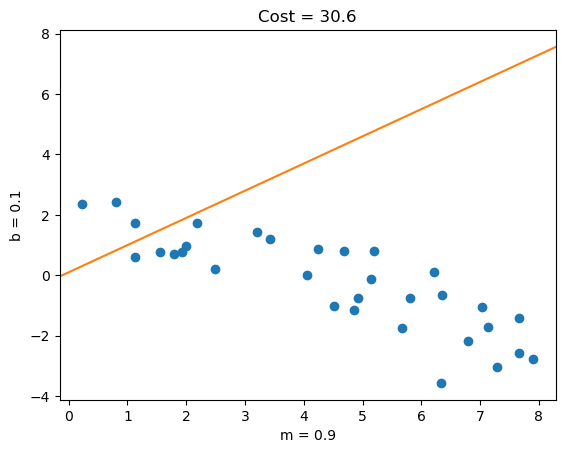

In [57]:
labeled_regression_plot(x[batch_indices], y[batch_indices], m, b, C, include_grad=False)

**Step 3**: Use autodiff to calculate gradient of $C$ w.r.t. parameters

In [58]:
C.backward()

In [59]:
m.grad

tensor([53.4475])

In [60]:
b.grad

tensor([8.5877])

The gradient of cost, $\nabla C$, is:

In [61]:
gradient = torch.tensor([[b.grad.item(), m.grad.item()]]).T
gradient

tensor([[ 8.5877],
        [53.4475]])

The vector of parameters $\boldsymbol{\theta}$ is:

In [62]:
theta = torch.tensor([[b, m]]).T
theta

tensor([[0.1000],
        [0.9000]])

**Step 4**: Gradient descent $$ \boldsymbol{\theta}' = \boldsymbol{\theta} - \alpha \nabla C $$

In [63]:
lr = 0.01

In [64]:
new_theta = theta - lr*gradient
new_theta

tensor([[0.0141],
        [0.3655]])

That's it! Let's update the `m` and `b` variables and confirm the correspond to a lower cost $C$:

In [65]:
b = new_theta[0]
m = new_theta[1]

In [66]:
C = mse(regression(x[batch_indices], m, b), y[batch_indices])
C

tensor(8.7904)

#### Rinse and Repeat

In [67]:
b.requires_grad_()
_ = m.requires_grad_()

Instead of looping through epochs, we'll loop through rounds of SGD:

In [68]:
rounds = 100 # Use additional rounds (e.g., 1000) for better fit (or use a "fancy" optimizer)
for r in range(rounds):

    # This sampling step is slow; we'll cover much quicker batch sampling later:
    batch_indices = np.random.choice(n, size=batch_size, replace=False)

    yhat = regression(x[batch_indices], m, b) # Step 1
    C = mse(yhat, y[batch_indices]) # Step 2

    C.backward() # Step 3: gradient computation

    if r % 10 == 0:
        print('Step {}, cost {}, m grad {}, b grad {}'.format(r, '%.3g' % C.item(), '%.3g' % m.grad.item(), '%.3g' % b.grad.item()))

    gradient = torch.tensor([[b.grad.item(), m.grad.item()]]).T
    theta = torch.tensor([[b, m]]).T

    new_theta = theta - lr*gradient # Step 4

    b = new_theta[0].requires_grad_()
    m = new_theta[1].requires_grad_()

Step 0, cost 8.31, m grad 27, b grad 4.04
Step 10, cost 1.85, m grad 3.36, b grad -0.397
Step 20, cost 1.54, m grad -2.39, b grad -1.15
Step 30, cost 2.32, m grad 0.31, b grad -1.26
Step 40, cost 2.11, m grad 0.0417, b grad -0.813
Step 50, cost 1.15, m grad -1.25, b grad -0.779
Step 60, cost 1.24, m grad -0.288, b grad -0.487
Step 70, cost 1.66, m grad 0.536, b grad -0.412
Step 80, cost 1.56, m grad -0.425, b grad -0.644
Step 90, cost 1.52, m grad 1.38, b grad -0.266


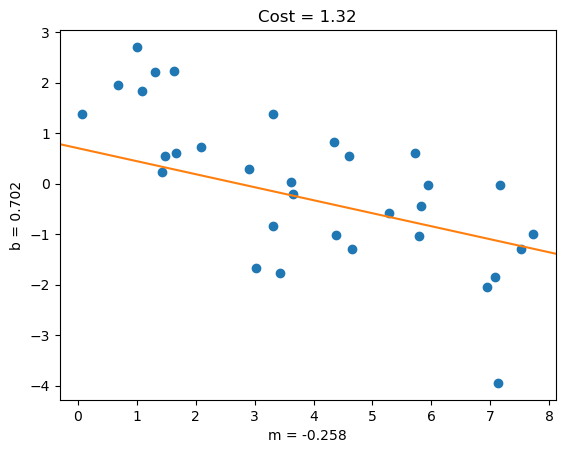

In [69]:
labeled_regression_plot(x[batch_indices], y[batch_indices], m, b, C, include_grad=False)

Since we have so many data points and we were sampling without replacement throughout this notebook, we can use our initial `indices` sample as model *validation data*:

In [70]:
validation_cost = mse(regression(x[indices], m, b), y[indices])

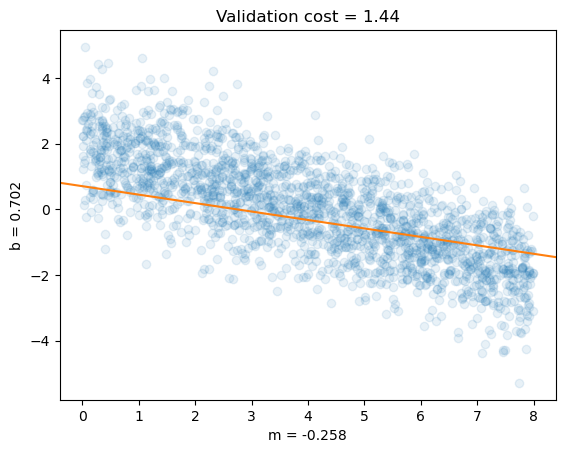

In [71]:
# Detach and convert tensors to numpy arrays for plotting:
x_np = x[indices].detach().numpy()
y_np = y[indices].detach().numpy()
m_val = m.detach()
b_val = b.detach()
validation_cost_val = validation_cost.detach()

fig, ax = plt.subplots()

ax.scatter(x_np, y_np, alpha=0.1)

x_min, x_max = ax.get_xlim()
y_min = regression(x_min, m_val, b_val)
y_max = regression(x_max, m_val, b_val)

plt.title('Validation cost = {}'.format('%.3g' % validation_cost_val.item()))
plt.ylabel('b = {}'.format('%.3g' % b_val.item()))
plt.xlabel('m = {}'.format('%.3g' % m_val.item()))

ax.set_xlim([x_min, x_max])
_ = ax.plot([x_min, x_max], [y_min, y_max], c='C01')

The model could fit the validation data better by being run for a thousand rounds instead of a hundred. However, using the batch-sampling method in this notebook is painfully slow. See the [*Learning Rate Scheduling* notebook](https://github.com/jonkrohn/ML-foundations/blob/master/notebooks/learning-rate-scheduling.ipynb), which builds on what we've done here to both more efficiently sample batches and refine the learning rate, thereby resulting in a much better-fitting model in a small fraction of the time.

### Learning Rate Scheduling

In SGD above, we used a fixed learning rate (`lr`) at every step.

Learning rate scheduling keeps the same SGD update, but changes `lr` during training: larger at the start for faster progress, then smaller later for smoother convergence.

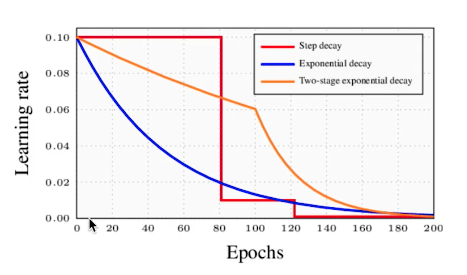

This notebook improves upon the SGD in above section by: 
1. Using efficient PyTorch `DataLoader()` iterable to batch data for SGD
2. Scheduling a variable learning rate

In [72]:
import torch
import matplotlib.pyplot as plt

#### Simulate data

In [73]:
_ = torch.manual_seed(42)

In [74]:
n = 8000000

In [75]:
x = torch.linspace(0., 8., n)

$$y = mx + b + \epsilon = -0.5x + 2 + \mathcal{N}(0, 1)$$

In [76]:
y = -0.5*x + 2 + torch.normal(mean=torch.zeros(n), std=1)

Randomly sample 2000 data points for model validation: 

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.00025, random_state=42)

In [79]:
x_valid.shape

torch.Size([2000])

In [80]:
x_train.shape

torch.Size([7998000])

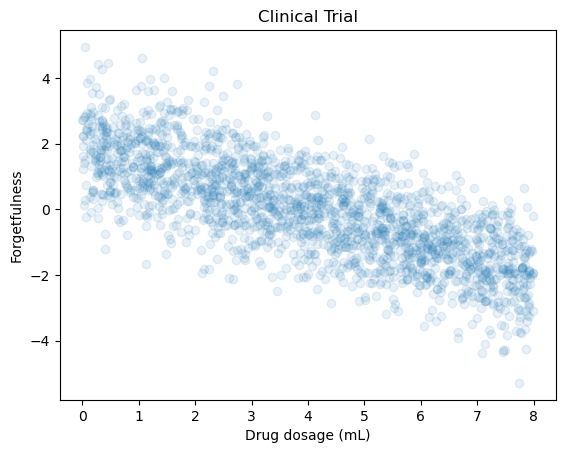

In [81]:
fig, ax = plt.subplots()
plt.title("Clinical Trial")
plt.xlabel("Drug dosage (mL)")
plt.ylabel("Forgetfulness")
_ = ax.scatter(x_valid, y_valid, alpha=0.1)

#### Define model and "randomly" initialize model parameters

In [82]:
def regression(my_x, my_m, my_b):
    return my_m*my_x + my_b

In [83]:
m = torch.tensor([0.9]).requires_grad_()
b = torch.tensor([0.1]).requires_grad_()

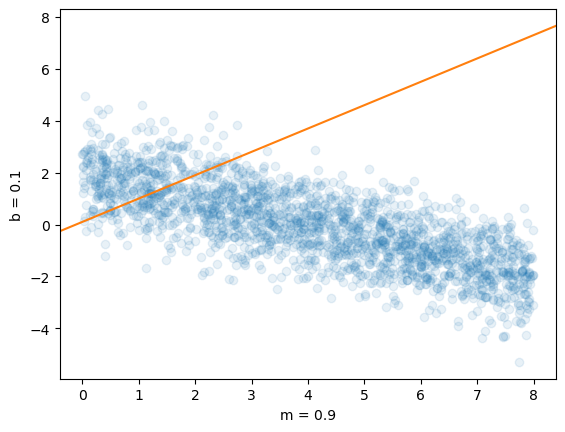

In [84]:
fig, ax = plt.subplots()

ax.scatter(x_valid, y_valid, alpha=0.1)

x_min, x_max = ax.get_xlim()
y_min = regression(x_min, m, b).detach().item()
y_max = regression(x_max, m, b).detach().item()

plt.ylabel('b = {}'.format('%.3g' % b.item()))
plt.xlabel('m = {}'.format('%.3g' % m.item()))

ax.set_xlim([x_min, x_max])
_ = ax.plot([x_min, x_max], [y_min, y_max], c='C01')

#### Optimize parameters via SGD

In [85]:
from torch.utils.data import TensorDataset, DataLoader

In [86]:
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32) # set shuffle=True if multiple epochs

In [87]:
x_batch, y_batch = next(iter(train_loader))

In [88]:
x_batch

tensor([7.9039, 2.5032, 2.1550, 6.1589, 7.1057, 6.6262, 6.6151, 7.5177, 6.4350,
        7.8031, 4.0389, 4.0771, 4.0771, 2.3573, 7.5437, 1.2994, 4.7333, 1.6890,
        1.4867, 1.0857, 7.9499, 7.7148, 4.1468, 4.9756, 7.8536, 3.7126, 2.7072,
        7.5391, 2.3218, 1.7388, 1.8237, 6.2415])

In [89]:
y_batch

tensor([-1.1923,  0.5152,  0.7512, -0.7778, -1.4118,  0.0496, -1.4554, -0.7491,
        -1.6638, -1.3719,  0.5347, -0.0260,  0.3292,  0.1032, -2.0465,  2.4188,
        -0.9180, -0.6667,  1.7137,  3.2658, -0.7733, -1.8584, -0.0086, -0.5010,
        -2.3102,  1.4706,  0.9627, -3.8245,  2.5656,  1.8036,  0.6060, -1.4121])

**Step 1**: Forward pass

In [90]:
yhat = regression(x_batch, m, b)
yhat

tensor([7.2135, 2.3529, 2.0395, 5.6430, 6.4952, 6.0636, 6.0536, 6.8659, 5.8915,
        7.1228, 3.7350, 3.7694, 3.7694, 2.2216, 6.8893, 1.2695, 4.3600, 1.6201,
        1.4380, 1.0771, 7.2549, 7.0433, 3.8321, 4.5781, 7.1682, 3.4414, 2.5365,
        6.8851, 2.1896, 1.6649, 1.7414, 5.7174], grad_fn=<AddBackward0>)

**Step 2**: Compare $\hat{y}$ with true $y$ to calculate cost $C$

In [91]:
def mse(my_yhat, my_y): 
    sigma = torch.sum((my_yhat - my_y)**2)
    return sigma/len(my_y)

In [92]:
C = mse(yhat, y_batch)
C

tensor(33.3355, grad_fn=<DivBackward0>)

In [93]:
def labeled_regression_plot(my_x, my_y, my_m, my_b, my_C, include_grad=True):
    
    title = 'Cost = {}'.format('%.3g' % my_C.item())
    if include_grad:
        xlabel = 'm = {}, m grad = {}'.format('%.3g' % my_m.item(), '%.3g' % my_m.grad.item())
        ylabel = 'b = {}, b grad = {}'.format('%.3g' % my_b.item(), '%.3g' % my_b.grad.item())
    else:
        xlabel = 'm = {}'.format('%.3g' % my_m.item())        
        ylabel = 'b = {}'.format('%.3g' % my_b.item())
    
    fig, ax = plt.subplots()
    
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)

    ax.scatter(my_x, my_y)
    
    x_min, x_max = ax.get_xlim()
    y_min = regression(x_min, my_m, my_b).detach().item()
    y_max = regression(x_max, my_m, my_b).detach().item()

    ax.set_xlim([x_min, x_max])
    _ = ax.plot([x_min, x_max], [y_min, y_max], c='C01')

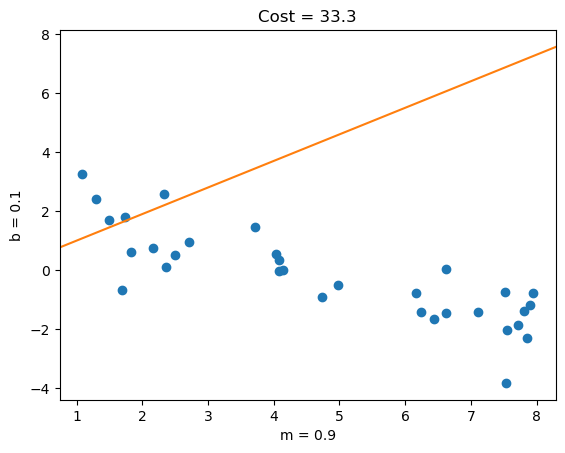

In [94]:
labeled_regression_plot(x_batch, y_batch, m, b, C, include_grad=False)

**Step 3**: Use autodiff to calculate gradient of $C$ w.r.t. parameters

In [95]:
C.backward()

In [96]:
gradient = torch.tensor([[b.grad.item(), m.grad.item()]]).T
gradient

tensor([[ 9.1138],
        [59.7826]])

In [97]:
theta = torch.tensor([[b, m]]).T 
theta

tensor([[0.1000],
        [0.9000]])

**Step 4**: Gradient descent $$ \boldsymbol{\theta}' = \boldsymbol{\theta} - \alpha \nabla C $$

In [98]:
lr = 0.02 # Doubled

In [99]:
new_theta = theta - lr*gradient
new_theta

tensor([[-0.0823],
        [-0.2957]])

Confirm $C$ is lower: 

In [100]:
b = new_theta[0]
m = new_theta[1]

In [101]:
C = mse(regression(x_batch, m, b), y_batch)
C

tensor(2.7568)

#### Rinse and Repeat

In [102]:
b.requires_grad_()
_ = m.requires_grad_() 

Set $\lambda$ hyperparameter for learning rate decay:

In [103]:
lambd = 0.995 # 'lambda' is a Python reserved term

In [104]:
lr = lambd * lr
lr

0.0199

In [105]:
rounds = 1000 
for r in range(rounds): 
    
    x_batch, y_batch = next(iter(train_loader)) # Efficient batching
    
    yhat = regression(x_batch, m, b) # Step 1
    C = mse(yhat, y_batch) # Step 2
    
    C.backward() # Step 3
    
    if r % 50 == 0:
        print('Step {}, cost {}, m grad {}, b grad {}, lr {}'.format(r, '%.3g' % C.item(), '%.3g' % m.grad.item(), '%.3g' % b.grad.item(), '%.3g' % lr))
    
    gradient = torch.tensor([[b.grad.item(), m.grad.item()]]).T
    theta = torch.tensor([[b, m]]).T 
    
    new_theta = theta - lr*gradient # Step 4
    
    b = new_theta[0].requires_grad_()
    m = new_theta[1].requires_grad_()
    
    lr = lambd * lr # Decay learning rate

Step 0, cost 2.76, m grad -9.63, b grad -2.6, lr 0.0199
Step 50, cost 1.32, m grad 0.113, b grad -0.67, lr 0.0155
Step 100, cost 1.07, m grad 0.0862, b grad -0.51, lr 0.0121
Step 150, cost 0.956, m grad 0.0698, b grad -0.413, lr 0.00938
Step 200, cost 0.893, m grad 0.0592, b grad -0.35, lr 0.0073
Step 250, cost 0.857, m grad 0.052, b grad -0.308, lr 0.00568
Step 300, cost 0.835, m grad 0.0471, b grad -0.279, lr 0.00442
Step 350, cost 0.821, m grad 0.0436, b grad -0.258, lr 0.00344
Step 400, cost 0.811, m grad 0.041, b grad -0.243, lr 0.00268
Step 450, cost 0.804, m grad 0.0391, b grad -0.232, lr 0.00209
Step 500, cost 0.799, m grad 0.0377, b grad -0.223, lr 0.00162
Step 550, cost 0.795, m grad 0.0367, b grad -0.217, lr 0.00126
Step 600, cost 0.793, m grad 0.0359, b grad -0.212, lr 0.000983
Step 650, cost 0.791, m grad 0.0353, b grad -0.209, lr 0.000765
Step 700, cost 0.789, m grad 0.0348, b grad -0.206, lr 0.000596
Step 750, cost 0.788, m grad 0.0344, b grad -0.204, lr 0.000464
Step 80

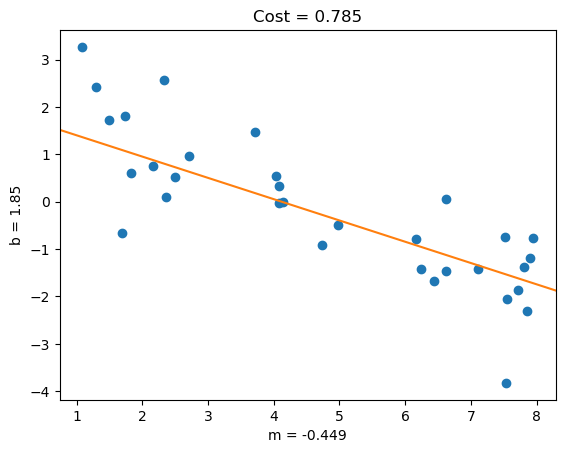

In [106]:
labeled_regression_plot(x_batch, y_batch, m, b, C, include_grad=False)

In [107]:
validation_cost = mse(regression(x_valid, m, b), y_valid)

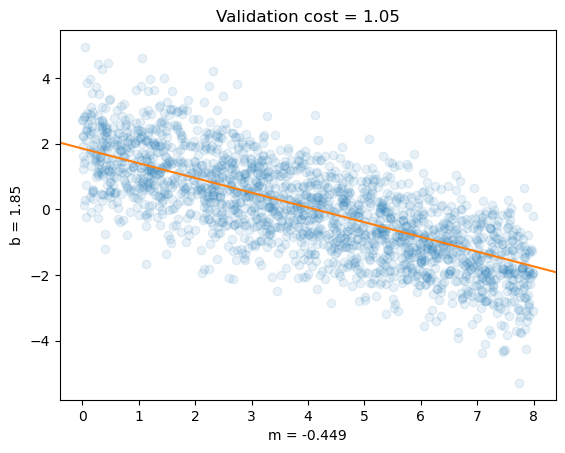

In [108]:
fig, ax = plt.subplots()

ax.scatter(x_valid, y_valid, alpha=0.1)

x_min, x_max = ax.get_xlim()
y_min = regression(x_min, m, b).detach().item()
y_max = regression(x_max, m, b).detach().item()

plt.title('Validation cost = {}'.format('%.3g' % validation_cost.item()))
plt.ylabel('b = {}'.format('%.3g' % b.item()))
plt.xlabel('m = {}'.format('%.3g' % m.item()))

ax.set_xlim([x_min, x_max])
_ = ax.plot([x_min, x_max], [y_min, y_max], c='C01')

Relative to the [*SGD from Scratch* notebook](https://github.com/jonkrohn/ML-foundations/blob/master/notebooks/SGD-from-scratch.ipynb): 

1. Carry out 1k SGD rounds in fraction of time it took to do 100
2. Lower validation cost due to more SGD rounds and (independently) learning rate scheduling

(Note that because of $\epsilon$ in the data simulation step, reaching zero cost on training data would only be possible with extreme overfitting and this would not correspond to improved fit on the validation data.)

## Segment 3: Fancy Deep Learning Optimizers

### Jacobian and Hessian Matrices

A *gradient* holds the partial derivatives of a function with vector input and scalar output. That is, $\boldsymbol{f}: \mathbb{R}^n \rightarrow \mathbb{R}$.

A **Jacobian matrix** holds the partial derivatives of a function with vector input *and vector output*. That is, if $\boldsymbol{f}: \mathbb{R}^m \rightarrow \mathbb{R}^n$. 

E.g., in the [*Artificial Neurons* notebook](https://github.com/jonkrohn/ML-foundations/blob/master/notebooks/artificial-neurons.ipynb), $m = 784$ and $n = 128$. In this case: 
* The Jacobian matrix $\boldsymbol{J}$ has 128 rows and 784 columns.
* Each element of $\boldsymbol{J}$ contains the partial derivative of a particular output element with respect to a particular input element: $J_{i,j} = \frac{\partial}{\partial x_j} f(\boldsymbol{x})_i$

Note that a *generalized Jacobian* holds the partial derivatives of a function with an input tensor of any dimensionality and an output tensor of any dimensionality.

A **Hessian matrix** is the Jacobian matrix of the gradient. Its elements hold all of the possible second derivatives of some function $f(\boldsymbol{x})$: 
$$ \boldsymbol{H}(f)(\boldsymbol{x})_{i,j} = \frac{\partial^2}{\partial x_i \partial x_j} f(\boldsymbol{x}) $$

Otherwise, refer to the slides and the following notebooks: 

* [*Artificial Neurons*](https://github.com/jonkrohn/ML-foundations/blob/master/notebooks/artificial-neurons.ipynb)
* [*Deep Net in TensorFlow* (1.x)](https://github.com/the-deep-learners/TensorFlow-LiveLessons/blob/master/notebooks/deep_net_in_tensorflow.ipynb)
* [*Deep Convolutional Net in TensorFlow* (1.x)](https://github.com/the-deep-learners/TensorFlow-LiveLessons/blob/master/notebooks/lenet_in_tensorflow.ipynb)
* [*Deep Convolutional Net in TensorFlow* (2.x, with Keras)](https://github.com/jonkrohn/DLTFpT/blob/master/notebooks/lenet_in_tensorflow.ipynb)
* [*Deep Net in PyTorch*](https://github.com/jonkrohn/DLTFpT/blob/master/notebooks/deep_net_in_pytorch.ipynb)